# Monte Carlo Prediction and Control for Reinforcement Learning

**Software:** Python, Gymnasium

**Comparison:** Monte Carlo **Prediction** (evaluates a fixed random policy) vs Monte Carlo
**Control** (learns and improves a policy via epsilon-Greedy GLIE Monte Carlo), both applied to
the same `FrozenLake-v1` environment so the comparison is fair.

```
Environment (Gymnasium)
        |
        v
Create Episode
        |
        v
Monte Carlo Prediction
        |
        v
Estimate State Values
        |
        v
Monte Carlo Control
        |
        v
Improve Policy
        |
        v
Compare Both Methods
        |
        v
Summary Table
        |
        v
Visualizations
```


## Cell 1 — Libraries & Environment Setup

```
Import Libraries
      |
      v
Import Gymnasium
      |
      v
Create FrozenLake Environment
      |
      v
Set Random Seed
      |
      v
Initialize Episodes
      |
      v
Discount Factor
      |
      v
Display Environment Information
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gymnasium as gym

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
np.set_printoptions(precision=2, suppress=True)

# ---------------------------------------------------------------
# Create FrozenLake Environment
# ---------------------------------------------------------------
ENV_NAME = "FrozenLake-v1"
env = gym.make(ENV_NAME, map_name="4x4", is_slippery=False)

# ---------------------------------------------------------------
# Set Random Seed
# ---------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
env.reset(seed=SEED)
env.action_space.seed(SEED)

# ---------------------------------------------------------------
# Initialize Episodes / Discount Factor
# ---------------------------------------------------------------
N_STATES = env.observation_space.n
N_ACTIONS = env.action_space.n
EPISODES = 1000
GAMMA = 0.99

ACTION_NAMES = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}
grid_desc = np.array([[cell.decode('utf-8') for cell in row] for row in env.unwrapped.desc])  # S/F/H/G layout

# ---------------------------------------------------------------
# Display Environment Information
# ---------------------------------------------------------------
env_params = pd.DataFrame({
    "Parameter": ["Environment", "Episodes", "States", "Actions", "Gamma", "Policy"],
    "Value": [ENV_NAME, EPISODES, N_STATES, N_ACTIONS, GAMMA, "Random"]
})

print("Gymnasium Environment Initialized")
print("=" * 35)
print("Map Layout (S=Start, F=Frozen, H=Hole, G=Goal):\n")
for row in grid_desc:
    print(' '.join(list(row)))
print()
env_params


Gymnasium Environment Initialized
Map Layout (S=Start, F=Frozen, H=Hole, G=Goal):

S F F F
F H F H
F F F H
H F F G



,Parameter,Value
0,Environment,FrozenLake-v1
1,Episodes,1000
2,States,16
3,Actions,4
4,Gamma,0.99
5,Policy,Random


## Cell 2 — Monte Carlo Prediction & Monte Carlo Control

```
Part A                          Part B
------                          ------
Monte Carlo Prediction          Monte Carlo Control
   |                               |
   v                               v
Random Policy                    Initialize epsilon-Greedy Policy
   |                               |
   v                               v
Generate Episodes                Generate Episode
   |                               |
   v                               v
Calculate Returns                Update Action Values
   |                               |
   v                               v
Update State Values              Improve Policy
   |                               |
   v                               v
Average Returns                  Repeat
   |                               |
   v                               v
Store Results                    Store Results
```

Both algorithms use **first-visit Monte Carlo** updates and run for the same number of
episodes on the same environment.


In [2]:
def generate_episode(env, policy_fn, max_steps=100):
    """Roll out one episode using policy_fn(state) -> action."""
    episode = []
    state, _ = env.reset()
    for _ in range(max_steps):
        action = policy_fn(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            break
    return episode


In [3]:
# =================================================================
# Part A: Monte Carlo Prediction (first-visit, fixed random policy)
# =================================================================

def monte_carlo_prediction(env, episodes, gamma, seed):
    rng = np.random.default_rng(seed)

    # ---- Random Policy ----
    def random_policy(state):
        return int(rng.integers(N_ACTIONS))

    V = np.zeros(N_STATES)
    returns_sum = np.zeros(N_STATES)
    returns_count = np.zeros(N_STATES)

    episode_returns = []

    start_time = time.perf_counter()
    for ep in range(episodes):
        # ---- Generate Episodes ----
        episode = generate_episode(env, random_policy)

        first_visit = {}
        for t, (s, a, r) in enumerate(episode):
            if s not in first_visit:
                first_visit[s] = t

        # ---- Calculate Returns (backward pass) ----
        G = 0.0
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r
            # ---- Update State Values / Average Returns (first-visit only) ----
            if first_visit[s] == t:
                returns_sum[s] += G
                returns_count[s] += 1
                V[s] = returns_sum[s] / returns_count[s]

        episode_return = G if len(episode) > 0 else 0.0
        episode_returns.append(episode_return)

    exec_time_ms = (time.perf_counter() - start_time) * 1000

    # ---- Average Returns (rolling, for the learning curve) ----
    rolling_avg = pd.Series(episode_returns).rolling(window=50, min_periods=1).mean().values
    final_avg_return = float(np.mean(episode_returns[-100:]))  # converged performance

    # ---- Store Results ----
    return {
        "V": V,
        "episode_returns": episode_returns,
        "rolling_avg": rolling_avg,
        "final_avg_return": final_avg_return,
        "returns_count": returns_count,
        "exec_time_ms": exec_time_ms,
    }


prediction_result = monte_carlo_prediction(env, EPISODES, GAMMA, seed=SEED)

state_value_table = pd.DataFrame({
    "State": np.arange(N_STATES),
    "Estimated Value": np.round(prediction_result["V"], 2)
})

print("Monte Carlo Prediction -- Estimated State Values\n")
state_value_table


Monte Carlo Prediction -- Estimated State Values



,State,Estimated Value
0,0,0.01
1,1,0.01
2,2,0.01
3,3,0.01
4,4,0.02
5,5,0.00
6,6,0.03
7,7,0.00
8,8,0.04
9,9,0.08


In [4]:
# =================================================================
# Part B: Monte Carlo Control (first-visit, on-policy epsilon-Greedy GLIE)
# =================================================================

def monte_carlo_control(env, episodes, gamma, epsilon_start, epsilon_end, seed):
    rng = np.random.default_rng(seed)

    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_sum = np.zeros((N_STATES, N_ACTIONS))
    returns_count = np.zeros((N_STATES, N_ACTIONS))

    # ---- Initialize epsilon-Greedy Policy ----
    # epsilon decays linearly (GLIE: Greedy in the Limit with Infinite Exploration)
    # so the agent explores heavily early on and exploits its learned Q-values later.
    def epsilon_greedy_policy(state, epsilon):
        if rng.random() < epsilon:
            return int(rng.integers(N_ACTIONS))
        return int(np.argmax(Q[state]))

    episode_returns = []

    start_time = time.perf_counter()
    for ep in range(episodes):
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * (ep / episodes)

        # ---- Generate Episode ----
        episode = generate_episode(env, lambda s: epsilon_greedy_policy(s, epsilon))

        first_visit = {}
        for t, (s, a, r) in enumerate(episode):
            if (s, a) not in first_visit:
                first_visit[(s, a)] = t

        # ---- Update Action Values (backward pass) ----
        G = 0.0
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r
            if first_visit[(s, a)] == t:
                returns_sum[s, a] += G
                returns_count[s, a] += 1
                Q[s, a] = returns_sum[s, a] / returns_count[s, a]
        # ---- Improve Policy ----
        # (implicit: epsilon_greedy_policy always reads the latest Q, so the
        #  policy improves automatically as soon as Q is updated above)

        episode_return = G if len(episode) > 0 else 0.0
        episode_returns.append(episode_return)
        # ---- Repeat happens via the for-loop over episodes ----

    exec_time_ms = (time.perf_counter() - start_time) * 1000
    best_actions = np.argmax(Q, axis=1)

    # ---- Average Returns (rolling, for the learning curve) ----
    rolling_avg = pd.Series(episode_returns).rolling(window=50, min_periods=1).mean().values
    final_avg_return = float(np.mean(episode_returns[-100:]))  # converged performance

    # ---- Store Results ----
    return {
        "Q": Q,
        "policy": best_actions,
        "episode_returns": episode_returns,
        "rolling_avg": rolling_avg,
        "final_avg_return": final_avg_return,
        "returns_count": returns_count,
        "exec_time_ms": exec_time_ms,
    }


control_result = monte_carlo_control(env, EPISODES, GAMMA, epsilon_start=1.0, epsilon_end=0.05, seed=SEED + 1)

best_action_table = pd.DataFrame({
    "State": np.arange(N_STATES),
    "Best Action": [ACTION_NAMES[a] for a in control_result["policy"]]
})

print("Monte Carlo Control -- Learned Policy\n")
best_action_table


Monte Carlo Control -- Learned Policy



,State,Best Action
0,0,Down
1,1,Left
2,2,Down
3,3,Up
4,4,Down
5,5,Left
6,6,Down
7,7,Left
8,8,Right
9,9,Down


## Cell 3 — Summary Table & Results

In [5]:
pred_converged_states = int(np.sum(prediction_result["returns_count"] > 0))
control_converged_states = int(np.sum(control_result["returns_count"].sum(axis=1) > 0))

# "Average Return" = mean return over the final 100 episodes, i.e. converged performance
pred_avg_return = prediction_result["final_avg_return"]
control_avg_return = control_result["final_avg_return"]

summary_table = pd.DataFrame({
    "Metric": ["Episodes", "Average Return", "Learned Policy", "State Values Estimated",
               "Policy Improvement", "Execution Time (ms)"],
    "MC Prediction": [EPISODES, f"{pred_avg_return:.2f}", "No", "Yes", "No",
                      f"{prediction_result['exec_time_ms']:.0f}"],
    "MC Control": [EPISODES, f"{control_avg_return:.2f}", "Yes", "Yes", "Yes",
                   f"{control_result['exec_time_ms']:.0f}"],
})

display(summary_table)

# ---------------------------------------------------------------
# Results
# ---------------------------------------------------------------
highest_return_method = "Monte Carlo Control" if control_avg_return >= pred_avg_return else "Monte Carlo Prediction"

print("\n==================================")
print("MONTE CARLO COMPARISON")
print("==================================")
print("Better State Value Estimation")
print("Monte Carlo Prediction\n")
print("Better Policy Learning")
print("Monte Carlo Control\n")
print("Highest Average Return")
print(f"{highest_return_method}\n")
print("Recommendation")
print("Monte Carlo Prediction is suitable for evaluating")
print("a fixed policy, whereas Monte Carlo Control")
print("iteratively improves the policy to maximize rewards.")


,Metric,MC Prediction,MC Control
0,Episodes,1000,1000
1,Average Return,0.01,0.82
2,Learned Policy,No,Yes
3,State Values Estimated,Yes,Yes
4,Policy Improvement,No,Yes
5,Execution Time (ms),122,121



MONTE CARLO COMPARISON
Better State Value Estimation
Monte Carlo Prediction

Better Policy Learning
Monte Carlo Control

Highest Average Return
Monte Carlo Control

Recommendation
Monte Carlo Prediction is suitable for evaluating
a fixed policy, whereas Monte Carlo Control
iteratively improves the policy to maximize rewards.


## Cell 4 — Visualizations

Three figures only:

1. **Learning Curve** — average return per episode (MC Prediction vs MC Control)
2. **State Value Heatmap** — Prediction vs Control state values, side by side
3. **Performance Comparison** — Average Return, Execution Time, Converged States


### Figure 1: Learning Curve

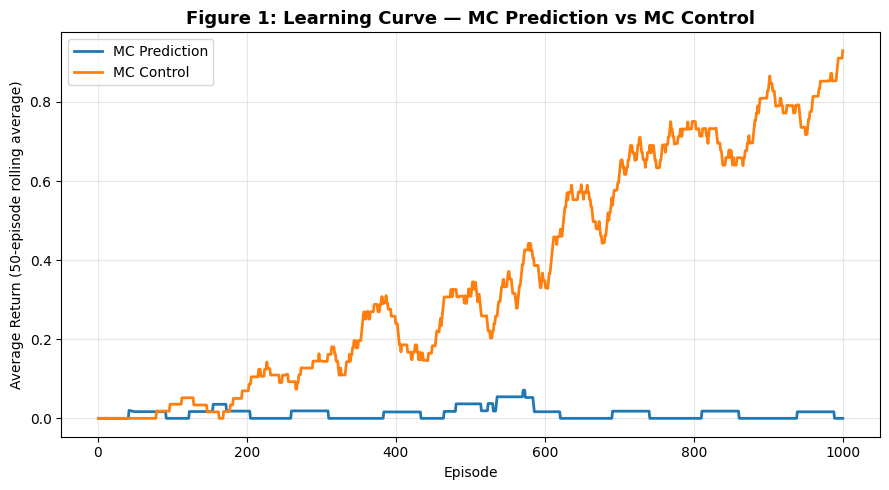

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

episodes_axis = np.arange(1, EPISODES + 1)
# Rolling average (window = 50 episodes) makes the learning trend visible;
# MC Prediction never changes its policy, so its curve stays flat and low,
# while MC Control's epsilon-decay schedule lets it climb toward the optimum.
ax.plot(episodes_axis, prediction_result["rolling_avg"],
        color="tab:blue", linewidth=2, label="MC Prediction")
ax.plot(episodes_axis, control_result["rolling_avg"],
        color="tab:orange", linewidth=2, label="MC Control")

ax.set_xlabel("Episode")
ax.set_ylabel("Average Return (50-episode rolling average)")
ax.set_title("Figure 1: Learning Curve — MC Prediction vs MC Control", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Figure 2: State Value Heatmap

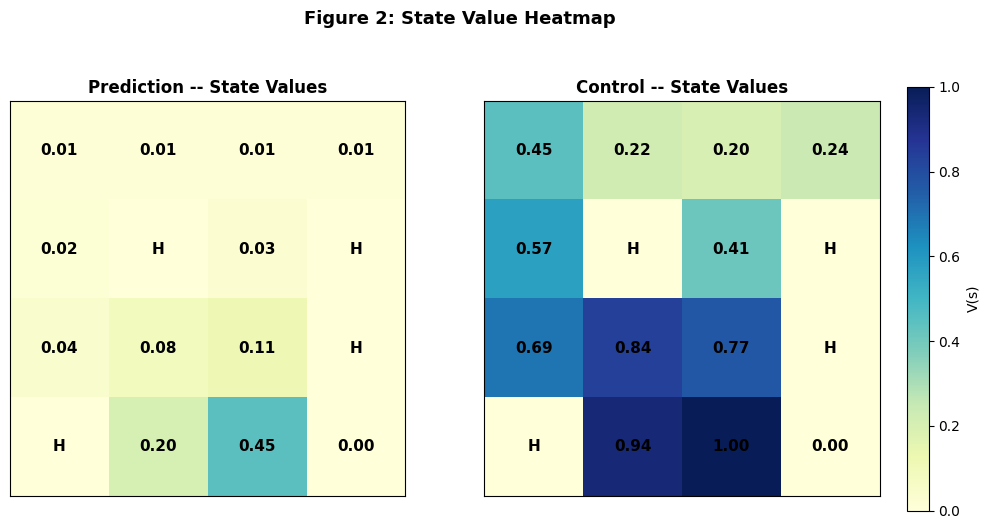

In [7]:
V_prediction_grid = prediction_result["V"].reshape(4, 4)
V_control_grid = np.max(control_result["Q"], axis=1).reshape(4, 4)  # state value under greedy policy

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

vmin = min(V_prediction_grid.min(), V_control_grid.min())
vmax = max(V_prediction_grid.max(), V_control_grid.max())

for ax, V_grid, title in zip(axes, [V_prediction_grid, V_control_grid],
                               ["Prediction -- State Values", "Control -- State Values"]):
    im = ax.imshow(V_grid, cmap="YlGnBu", vmin=vmin, vmax=vmax)
    for r in range(4):
        for c in range(4):
            cell_type = grid_desc[r][c]
            label = f"{V_grid[r, c]:.2f}" if cell_type != 'H' else "H"
            ax.text(c, r, label, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight="bold")

fig.colorbar(im, ax=axes, fraction=0.035, pad=0.03, label="V(s)")
fig.suptitle("Figure 2: State Value Heatmap", fontsize=13, fontweight="bold", y=1.02)
plt.show()


### Figure 3: Performance Comparison

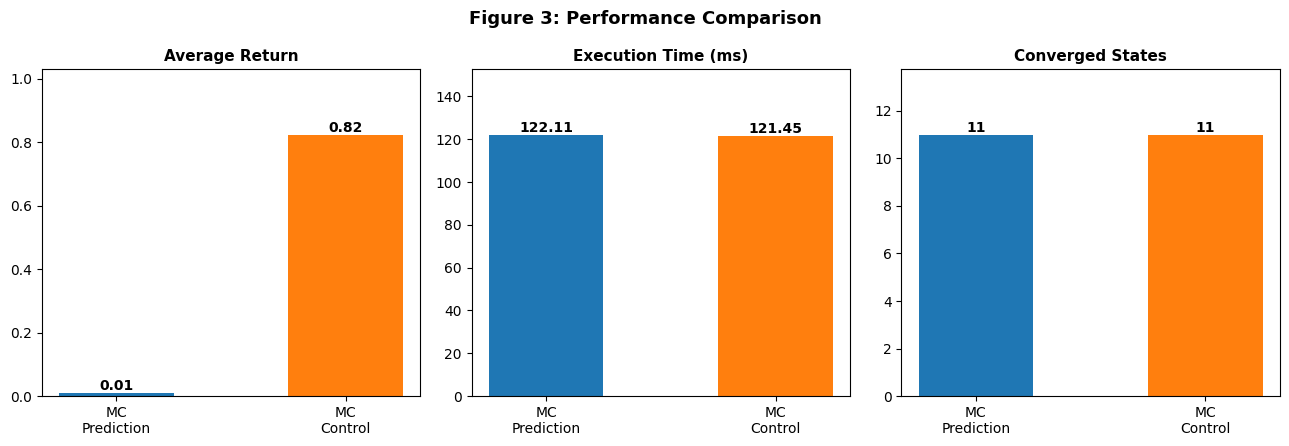

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

metrics = [
    ("Average Return", [pred_avg_return, control_avg_return]),
    ("Execution Time (ms)", [prediction_result["exec_time_ms"], control_result["exec_time_ms"]]),
    ("Converged States", [pred_converged_states, control_converged_states]),
]
labels = ["MC\nPrediction", "MC\nControl"]
colors = ["tab:blue", "tab:orange"]

for ax, (title, values) in zip(axes, metrics):
    bars = ax.bar(labels, values, color=colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.2f}" if isinstance(val, float) else str(val),
                 ha="center", va="bottom", fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)

fig.suptitle("Figure 3: Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
